In [1]:
# Cell 1: Installation
!pip install opencv-python easyocr matplotlib torch torchvision

In [2]:
import os
import cv2
import easyocr
import matplotlib.pyplot as plt


reader = easyocr.Reader(['en'], gpu=False)


base_dir = os.path.join(os.getcwd(), 'data')
if not os.path.isdir(os.path.join(base_dir, 'Real')):
    base_dir = os.path.abspath(os.path.join(os.getcwd(), '..', 'data'))

train_dir = os.path.join(base_dir, 'train')
real_path = os.path.join(base_dir, 'Real')
fake_path = os.path.join(base_dir, 'Fake')


if os.path.isdir(real_path) and os.path.isdir(fake_path):
    print("Path is correct.")
    print(f"Real Images Folder: {real_path}")
    print(f"Fake Images Folder: {fake_path}")
else:
    raise FileNotFoundError(
        f"Dataset folders not found. Expected Real and Fake under: {base_dir}"
    )

Using CPU. Note: This module is much faster with a GPU.


C:\LKANTA\ALL_PROJECTS\Fake-Mediceine-detector\.venv\Lib\site-packages\torch\ao\nn\quantized\dynamic\modules\rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\quantized\Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(


Path is correct.
Real Images Folder: C:\LKANTA\ALL_PROJECTS\Fake-Mediceine-detector\data\Real
Fake Images Folder: C:\LKANTA\ALL_PROJECTS\Fake-Mediceine-detector\data\Fake



Testing REAL Medicine:
Scanning text...


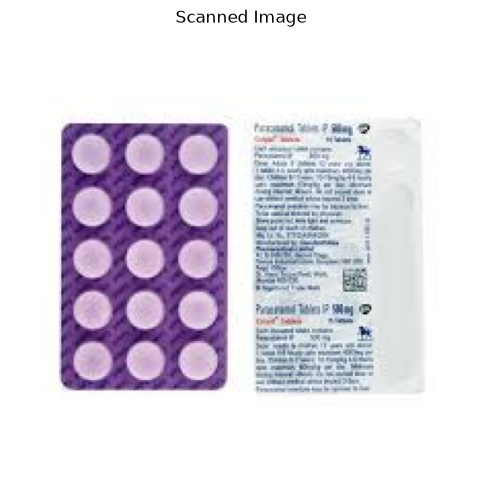


--- Detected Text ---

Testing FAKE Medicine:
Scanning text...


C:\LKANTA\ALL_PROJECTS\Fake-Mediceine-detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


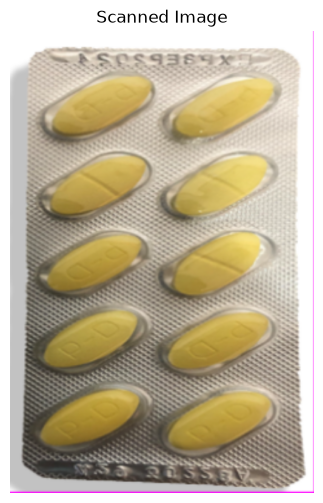


--- Detected Text ---


In [3]:
# Cell 3: OCR Function & Visualisation

def detect_text(image_path):
    img = cv2.imread(image_path)

    if img is None:
        print(f"Error: Image nahi khul rahi - {image_path}")
        return

    print("Scanning text...")
    results = reader.readtext(img)

    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Scanned Image")
    plt.show()

    print("\n--- Detected Text ---")
    extracted_text = []
    for (bbox, text, prob) in results:
        if prob > 0.3:
            print(f"Text: {text}  (Confidence: {prob:.2f})")
            extracted_text.append(text)

    return extracted_text


image_extensions = ('.jpg', '.png', '.jpeg')
real_images = [
    name for name in os.listdir(real_path)
    if name.lower().endswith(image_extensions)
]
fake_images = [
    name for name in os.listdir(fake_path)
    if name.lower().endswith(image_extensions)
]

print("\nTesting REAL Medicine:")
if real_images:
    detect_text(os.path.join(real_path, real_images[0]))
else:
    print("No real medicine images found.")

print("\nTesting FAKE Medicine:")
if fake_images:
    detect_text(os.path.join(fake_path, fake_images[0]))
else:
    print("No fake medicine images found.")

In [4]:
import pandas as pd
from tqdm import tqdm 

dataset = []

def process_folder(folder_path, label, limit=50):
    print(f"\n📂 Processing {label} folder (Limit: {limit} images)...")
    
    all_files = os.listdir(folder_path)
    image_files = [f for f in all_files if f.endswith(('.jpg', '.png', '.jpeg'))]
    
    for file_name in tqdm(image_files[:limit]):
        full_path = os.path.join(folder_path, file_name)
        
        try:
            img = cv2.imread(full_path)
            
            text_results = reader.readtext(img, detail=0) 
            
            full_text = " ".join(text_results)
            
            dataset.append({
                "Filename": file_name,
                "Text": full_text,
                "Label": label
            })
            
        except Exception as e:
            print(f"Skipping {file_name}: {e}")

process_folder(real_path, label="Real", limit=50)


process_folder(fake_path, label="Fake", limit=50)

df = pd.DataFrame(dataset)

df.to_csv("medicine_dataset.csv", index=False)

print("\n✅ Processing Complete!")
print(f"Total Images Processed: {len(df)}")
print("Data 'medicine_dataset.csv'")

df.head()


📂 Processing Real folder (Limit: 50 images)...


  0%|          | 0/50 [00:00<?, ?it/s]

  2%|▏         | 1/50 [00:00<00:20,  2.41it/s]

C:\LKANTA\ALL_PROJECTS\Fake-Mediceine-detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  4%|▍         | 2/50 [00:01<00:24,  1.92it/s]

...

 98%|█████████▊| 49/50 [05:59<00:14, 14.17s/it]

100%|██████████| 50/50 [06:04<00:00, 11.50s/it]

100%|██████████| 50/50 [06:04<00:00,  7.29s/it]


✅ Processing Complete!
Total Images Processed: 100
Data 'medicine_dataset.csv'


,Filename,Text,Label
0,images01.jpg,,Real
1,images02.jpg,Paracetamo Tablets IP 500 mg Calpol 500],Real
2,images03.jpg,Tobs5s|F naleeln llt telmmtu,Real
3,images04.jpg,Paracetamol Tablets SC0 Iiq Calpol& 1531 KeA T...,Real
4,images05.jpg,,Real


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report


if 'Text' not in df.columns or 'Label' not in df.columns:
    raise ValueError("The dataset must contain 'Text' and 'Label' columns.")

df_clean = df[['Text', 'Label']].copy()
df_clean['Text'] = df_clean['Text'].fillna('').astype(str).str.strip()
df_clean = df_clean[df_clean['Text'] != '']
df_clean = df_clean.dropna(subset=['Label'])

if len(df_clean) < 4:
    raise ValueError(
        "Not enough usable OCR text to train the model. "
        "Run the OCR processing cell first and check that Text is not empty."
    )

label_counts = df_clean['Label'].value_counts()
if len(label_counts) < 2:
    raise ValueError(
        "Training requires both Real and Fake labels. "
        f"Found: {label_counts.to_dict()}"
    )

print(f"Total usable data: {len(df_clean)} samples")

test_size = 2 if len(df_clean) < 10 else 0.2
stratify_labels = df_clean['Label'] if label_counts.min() >= 2 else None
X_train, X_test, y_train, y_test = train_test_split(
    df_clean['Text'],
    df_clean['Label'],
    test_size=test_size,
    random_state=42,
    stratify=stratify_labels
)

model = make_pipeline(TfidfVectorizer(), MultinomialNB())

print("Model training starts...")
model.fit(X_train, y_train)
print("Training complete!")

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"\nModel Accuracy: {accuracy * 100:.2f}%")
print("\n--- Detailed Report ---")
print(classification_report(y_test, predictions, zero_division=0))

Total usable data: 75 samples
Model training starts...
Training complete!

Model Accuracy: 100.00%

--- Detailed Report ---
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00         9
        Real       1.00      1.00      1.00         6

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



In [6]:
def predict_medicine(text_from_ocr):
    prediction = model.predict([text_from_ocr])[0]
    probability = model.predict_proba([text_from_ocr]).max() * 100
    
    return prediction, probability

sample_text_fake = "Paracitamol 500mg Batch:X99 Exp:2026" 
sample_text_real = "Paracetamol 500mg Batch:A12 Exp:2025" 

pred_fake, prob_fake = predict_medicine(sample_text_fake)
pred_real, prob_real = predict_medicine(sample_text_real)

print(f"Test 1 Text: '{sample_text_fake}'")
print(f"👉 Prediction: {pred_fake} ({prob_fake:.2f}%)")
print("-" * 30)
print(f"Test 2 Text: '{sample_text_real}'")
print(f"👉 Prediction: {pred_real} ({prob_real:.2f}%)")

Test 1 Text: 'Paracitamol 500mg Batch:X99 Exp:2026'
👉 Prediction: Fake (56.67%)
------------------------------
Test 2 Text: 'Paracetamol 500mg Batch:A12 Exp:2025'
👉 Prediction: Fake (55.47%)


In [7]:
import joblib 

dataset = []

print(" Full Data Processing Starts....")

process_folder(real_path, label="Real", limit=None) 

process_folder(fake_path, label="Fake", limit=None)

df = pd.DataFrame(dataset)
df.to_csv("full_medicine_dataset.csv", index=False)
print(f"Data Processed! Total Images: {len(df)}")


df_clean = df[df['Text'].str.strip() != ""].copy()
X_train, X_test, y_train, y_test = train_test_split(df_clean['Text'], df_clean['Label'], test_size=0.2)


model = make_pipeline(TfidfVectorizer(), MultinomialNB())
model.fit(X_train, y_train)

acc = accuracy_score(y_test, model.predict(X_test))
print(f"New Model Accuracy: {acc * 100:.2f}%")

joblib.dump(model, 'medicine_model.pkl')
print(" Model saved as 'medicine_model.pkl'")

 Full Data Processing Starts....

📂 Processing Real folder (Limit: None images)...


  0%|          | 0/421 [00:00<?, ?it/s]

  0%|          | 1/421 [00:00<06:42,  1.04it/s]

C:\LKANTA\ALL_PROJECTS\Fake-Mediceine-detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  0%|          | 2/421 [00:02<08:24,  1.20s/it]

...

 99%|█████████▉| 238/240 [40:06<00:16,  8.26s/it]

100%|█████████▉| 239/240 [40:21<00:10, 10.54s/it]

100%|██████████| 240/240 [40:29<00:00,  9.66s/it]

100%|██████████| 240/240 [40:29<00:00, 10.12s/it]

Data Processed! Total Images: 661
New Model Accuracy: 71.72%
 Model saved as 'medicine_model.pkl'


In [8]:
import os
import joblib

current_location = os.getcwd()
print(f"📍 folder:\n{current_location}")

file_path = os.path.join(current_location, 'medicine_model.pkl')

if os.path.exists(file_path):
    print("\n File is here.")
    print(f"File ka naam: medicine_model.pkl")
else:
    print("\n File is not here.")
    
    try:
        if 'model' in globals():
            print("\n⚙️ Model is inside memory ...")
            joblib.dump(model, 'medicine_model.pkl')
            print("✅ Ab save ho gayi! Folder refresh karke dekhein.")
        else:
            print("⚠️ Model memory mein nahi hai. Lagta hai aapne Training wala code run nahi kiya ya Notebook band kar di thi.")
            print("Upaya: Upar wala 'Step 1: Poora Data Process' code dobara run karein.")
    except:
        pass

📍 folder:
C:\LKANTA\ALL_PROJECTS\Fake-Mediceine-detector\notebooks

 File is here.
File ka naam: medicine_model.pkl
